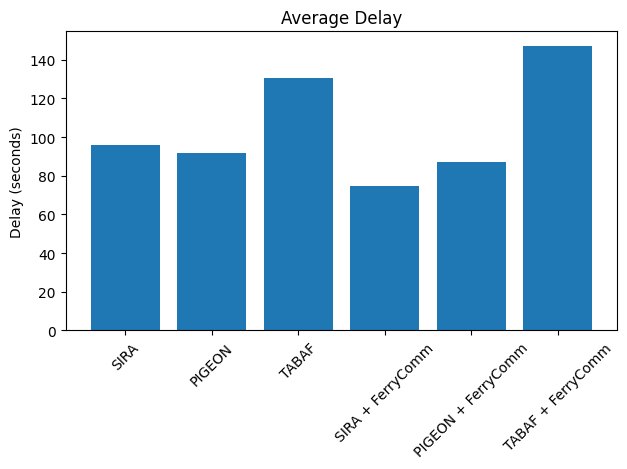

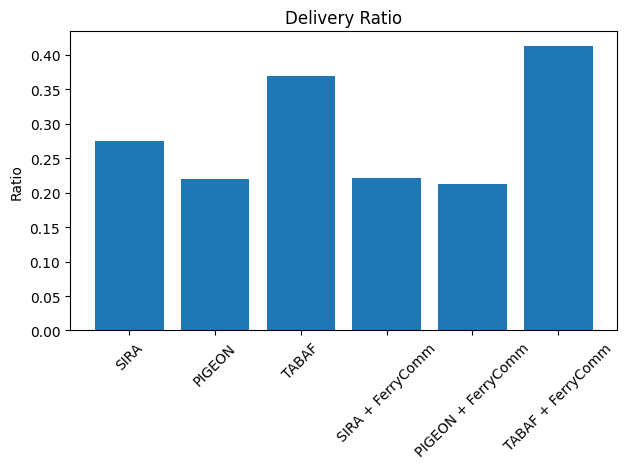

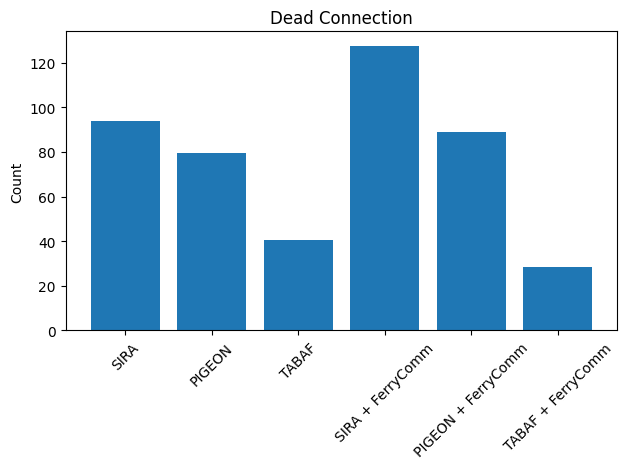

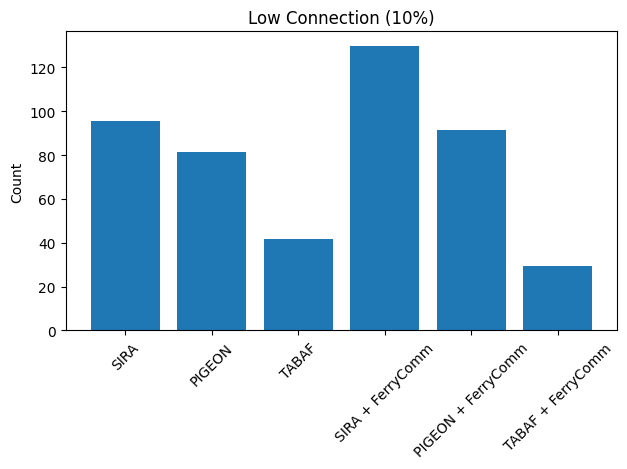

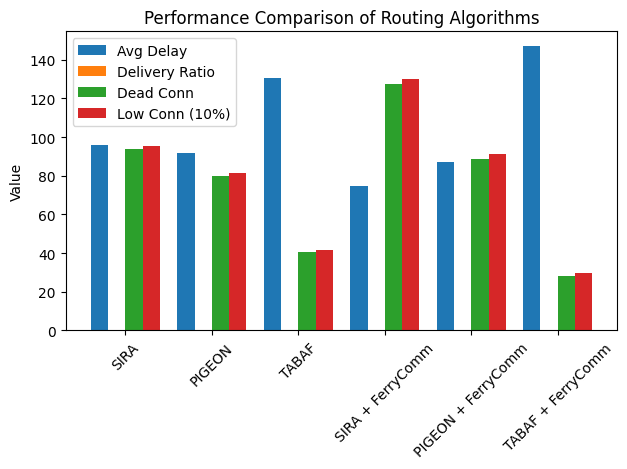

In [3]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import regex

# ==============================
# CONFIG
# ==============================
REPORT_DIR = "../report"  # thư mục chứa report
LOW_CONN_LEVEL = "10%"  # chọn mức Low Connection muốn vẽ

# ==============================
# REGEX
# ==============================

regex_algo = re.compile(r"(SIRA|PIGEON|TABAF)")


def get_value(value_name: str, content: str):
    lines = content.split("\n")
    for line in lines:
        if line.startswith(value_name):
            line = line.split(":")[1]
            line = line.strip().split(" ")[0]
            return line


# ==============================
# DATA STRUCTURE
# ==============================
# key: setup_name
# value: list of metric dict
data = defaultdict(list)

# ==============================
# READ FILES
# ==============================
for filename in os.listdir(REPORT_DIR):
    if not filename.__contains__("202602"):
        continue
    filepath = os.path.join(REPORT_DIR, filename)

    if not os.path.isfile(filepath):
        continue

    with open(filepath, "r") as f:
        content = f.read()

    # Determine algorithm
    algo_match = regex_algo.search(filename)
    if not algo_match:
        continue
    algo = algo_match.group(1)

    # Determine ferry communication
    ferry_match = get_value("Enable Ferry Communication", content)
    ferry_enabled = bool(int(ferry_match))

    # Build setup name
    setup_name = algo
    if ferry_enabled:
        setup_name += " + FerryComm"

    # Extract metrics
    avg_delay = float(get_value("Average Delay", content))
    delivery_ratio = float(get_value("Delivery Ratio", content))
    dead_conn = int(get_value("Dead Connection", content))
    low_conn = int(get_value(f"Low Connection ({LOW_CONN_LEVEL})", content))

    data[setup_name].append(
        {
            "avg_delay": avg_delay,
            "delivery_ratio": delivery_ratio,
            "dead_conn": dead_conn,
            "low_conn": low_conn,
        }
    )

# ==============================
# COMPUTE MEAN (5 runs)
# ==============================
final_results = {}

for setup, runs in data.items():
    avg_delay = np.mean([r["avg_delay"] for r in runs])
    delivery_ratio = np.mean([r["delivery_ratio"] for r in runs])
    dead_conn = np.mean([r["dead_conn"] for r in runs])
    low_conn = np.mean([r["low_conn"] for r in runs])

    final_results[setup] = {
        "avg_delay": avg_delay,
        "delivery_ratio": delivery_ratio,
        "dead_conn": dead_conn,
        "low_conn": low_conn,
    }

# Order of setups
setup_order = [
    "SIRA",
    "PIGEON",
    "TABAF",
    "SIRA + FerryComm",
    "PIGEON + FerryComm",
    "TABAF + FerryComm",
]


# ==============================
# PLOT FUNCTION
# ==============================
def plot_metric(metric_key, title, ylabel):
    x_labels = []
    y_values = []

    for setup in setup_order:
        if setup in final_results:
            x_labels.append(setup)
            y_values.append(final_results[setup][metric_key])

    plt.figure()
    plt.bar(x_labels, y_values)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


# ==============================
# DRAW PLOTS
# ==============================

plot_metric("avg_delay", "Average Delay", "Delay (seconds)")
plot_metric("delivery_ratio", "Delivery Ratio", "Ratio")
plot_metric("dead_conn", "Dead Connection", "Count")
plot_metric("low_conn", f"Low Connection ({LOW_CONN_LEVEL})", "Count")

# ==============================
# DRAW SINGLE FIGURE
# ==============================

metrics = ["avg_delay", "delivery_ratio", "dead_conn", "low_conn"]
metric_labels = [
    "Avg Delay",
    "Delivery Ratio",
    "Dead Conn",
    f"Low Conn ({LOW_CONN_LEVEL})",
]

x = np.arange(len(setup_order))
width = 0.2  # độ rộng mỗi bar

plt.figure()

for i, metric in enumerate(metrics):
    values = []
    for setup in setup_order:
        if setup in final_results:
            values.append(final_results[setup][metric])
        else:
            values.append(0)

    plt.bar(x + i * width, values, width, label=metric_labels[i])

plt.xticks(x + width * 1.5, setup_order, rotation=45)
plt.ylabel("Value")
plt.title("Performance Comparison of Routing Algorithms")
plt.legend()
plt.tight_layout()
plt.show()

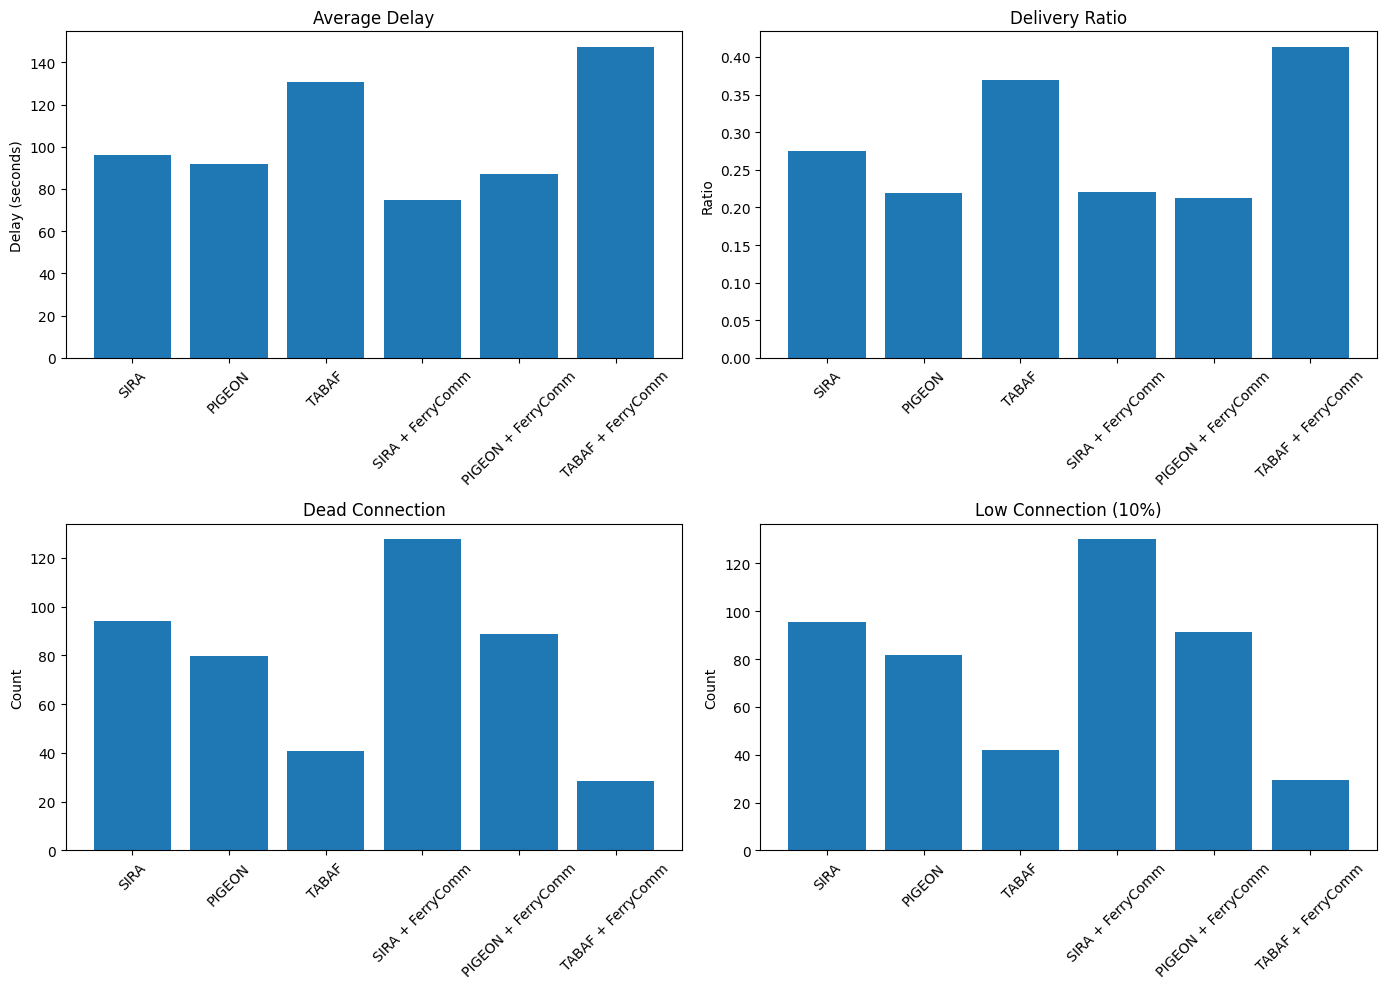

In [ ]:
# ==============================
# DRAW 4 SUBPLOTS IN ONE FIGURE
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ("avg_delay", "Average Delay", "Delay (seconds)"),
    ("delivery_ratio", "Delivery Ratio", "Ratio"),
    ("dead_conn", "Dead Connection", "Count"),
    ("low_conn", f"Low Connection ({LOW_CONN_LEVEL})", "Count"),
]

for ax, (metric_key, title, ylabel) in zip(axes.flatten(), metrics):
    x_labels = []
    y_values = []

    for setup in setup_order:
        if setup in final_results:
            x_labels.append(setup)
            y_values.append(final_results[setup][metric_key])

    ax.bar(x_labels, y_values)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()